In [90]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer


from torch.distributions.log_normal import LogNormal
from torch.distributions.normal import Normal

In [69]:
# dimension 1 = M_sat
num_dim = 1

# uniform distribution from 0.00001 ~ 1
prior = utils.BoxUniform(low = 0.00001 * torch.ones(num_dim), high = 1 * torch.ones(num_dim))

In [100]:
# lognormal distribution ~(0.01, 1)
prior = LogNormal(torch.tensor([0.0]), torch.tensor([1.0]))

In [32]:
# normal distribution ~(0.5, 0.1)
prior = Normal(0.5, 0.1)

In [98]:
prior = torch.distributions.chi2.Chi2(torch.tensor([1.0]))

In [92]:
def simple_relation(positions, M_sat):
    
    # phi2 values depend on phi1 & M_sat
    for i in range(0, 100):
        positions[i]= positions[i]/M_sat[0] + torch.randn_like(M_sat) * 0.1
    
    return torch.as_tensor(positions)

In [101]:
def simulator(M_sat):
    # phi1 values evenly spaced between [0,50)
    initial_positions = list()
    for i in range(0, 100):
        initial_positions += [0.5*i]
    # print(initial_positions)

    return simple_relation(initial_positions, M_sat)

In [73]:
# # calculate the expected observation values 
# positions = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5, 42.0, 42.5, 43.0, 43.5, 44.0, 44.5, 45.0, 45.5, 46.0, 46.5, 47.0, 47.5, 48.0, 48.5, 49.0, 49.5]
# M_sat = [0.7]
# for i in range(0, 100):
#         positions[i]= positions[i]/M_sat[0]
# print(positions)

[0.0, 0.7142857142857143, 1.4285714285714286, 2.142857142857143, 2.857142857142857, 3.5714285714285716, 4.285714285714286, 5.0, 5.714285714285714, 6.428571428571429, 7.142857142857143, 7.857142857142858, 8.571428571428571, 9.285714285714286, 10.0, 10.714285714285715, 11.428571428571429, 12.142857142857144, 12.857142857142858, 13.571428571428573, 14.285714285714286, 15.000000000000002, 15.714285714285715, 16.42857142857143, 17.142857142857142, 17.857142857142858, 18.571428571428573, 19.28571428571429, 20.0, 20.714285714285715, 21.42857142857143, 22.142857142857146, 22.857142857142858, 23.571428571428573, 24.28571428571429, 25.0, 25.714285714285715, 26.42857142857143, 27.142857142857146, 27.857142857142858, 28.571428571428573, 29.28571428571429, 30.000000000000004, 30.714285714285715, 31.42857142857143, 32.142857142857146, 32.85714285714286, 33.57142857142858, 34.285714285714285, 35.0, 35.714285714285715, 36.42857142857143, 37.142857142857146, 37.85714285714286, 38.57142857142858, 39.285

In [102]:
posterior = infer(simulator, prior, "SNRE", num_simulations=100)


Running 100 simulations.: 100%|██████████| 100/100 [00:00<00:00, 419.00it/s]


 Neural network successfully converged after 354 epochs.

In [103]:
# M_sat = [0.1]
observation1 = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 100.0, 105.0, 110.0, 115.0, 120.0, 125.0, 130.0, 135.0, 140.0, 145.0, 150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0, 300.0, 305.0, 310.0, 315.0, 320.0, 325.0, 330.0, 335.0, 340.0, 345.0, 350.0, 355.0, 360.0, 365.0, 370.0, 375.0, 380.0, 385.0, 390.0, 395.0, 400.0, 405.0, 410.0, 415.0, 420.0, 425.0, 430.0, 435.0, 440.0, 445.0, 450.0, 455.0, 460.0, 465.0, 470.0, 475.0, 480.0, 485.0, 490.0, 495.0]

# M_sat = [0.9]
observation2= [0.0, 0.5555555555555556, 1.1111111111111112, 1.6666666666666665, 2.2222222222222223, 2.7777777777777777, 3.333333333333333, 3.888888888888889, 4.444444444444445, 5.0, 5.555555555555555, 6.111111111111111, 6.666666666666666, 7.222222222222222, 7.777777777777778, 8.333333333333334, 8.88888888888889, 9.444444444444445, 10.0, 10.555555555555555, 11.11111111111111, 11.666666666666666, 12.222222222222221, 12.777777777777777, 13.333333333333332, 13.88888888888889, 14.444444444444445, 15.0, 15.555555555555555, 16.11111111111111, 16.666666666666668, 17.22222222222222, 17.77777777777778, 18.333333333333332, 18.88888888888889, 19.444444444444443, 20.0, 20.555555555555554, 21.11111111111111, 21.666666666666668, 22.22222222222222, 22.77777777777778, 23.333333333333332, 23.88888888888889, 24.444444444444443, 25.0, 25.555555555555554, 26.11111111111111, 26.666666666666664, 27.22222222222222, 27.77777777777778, 28.333333333333332, 28.88888888888889, 29.444444444444443, 30.0, 30.555555555555554, 31.11111111111111, 31.666666666666664, 32.22222222222222, 32.77777777777778, 33.333333333333336, 33.888888888888886, 34.44444444444444, 35.0, 35.55555555555556, 36.11111111111111, 36.666666666666664, 37.22222222222222, 37.77777777777778, 38.333333333333336, 38.888888888888886, 39.44444444444444, 40.0, 40.55555555555556, 41.11111111111111, 41.666666666666664, 42.22222222222222, 42.77777777777778, 43.333333333333336, 43.888888888888886, 44.44444444444444, 45.0, 45.55555555555556, 46.11111111111111, 46.666666666666664, 47.22222222222222, 47.77777777777778, 48.33333333333333, 48.888888888888886, 49.44444444444444, 50.0, 50.55555555555556, 51.11111111111111, 51.666666666666664, 52.22222222222222, 52.77777777777778, 53.33333333333333, 53.888888888888886, 54.44444444444444, 55.0]

# M_sat = [0.5]
observation3= [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0]

# M_sat = [0.3]
observation4 = [0.0, 1.6666666666666667, 3.3333333333333335, 5.0, 6.666666666666667, 8.333333333333334, 10.0, 11.666666666666668, 13.333333333333334, 15.0, 16.666666666666668, 18.333333333333336, 20.0, 21.666666666666668, 23.333333333333336, 25.0, 26.666666666666668, 28.333333333333336, 30.0, 31.666666666666668, 33.333333333333336, 35.0, 36.66666666666667, 38.333333333333336, 40.0, 41.66666666666667, 43.333333333333336, 45.0, 46.66666666666667, 48.333333333333336, 50.0, 51.66666666666667, 53.333333333333336, 55.0, 56.66666666666667, 58.333333333333336, 60.0, 61.66666666666667, 63.333333333333336, 65.0, 66.66666666666667, 68.33333333333334, 70.0, 71.66666666666667, 73.33333333333334, 75.0, 76.66666666666667, 78.33333333333334, 80.0, 81.66666666666667, 83.33333333333334, 85.0, 86.66666666666667, 88.33333333333334, 90.0, 91.66666666666667, 93.33333333333334, 95.0, 96.66666666666667, 98.33333333333334, 100.0, 101.66666666666667, 103.33333333333334, 105.0, 106.66666666666667, 108.33333333333334, 110.0, 111.66666666666667, 113.33333333333334, 115.0, 116.66666666666667, 118.33333333333334, 120.0, 121.66666666666667, 123.33333333333334, 125.0, 126.66666666666667, 128.33333333333334, 130.0, 131.66666666666669, 133.33333333333334, 135.0, 136.66666666666669, 138.33333333333334, 140.0, 141.66666666666669, 143.33333333333334, 145.0, 146.66666666666669, 148.33333333333334, 150.0, 151.66666666666669, 153.33333333333334, 155.0, 156.66666666666669, 158.33333333333334, 160.0, 161.66666666666669, 163.33333333333334, 165.0]

# M_sat = [0.7]
observation5 = [0.0, 0.7142857142857143, 1.4285714285714286, 2.142857142857143, 2.857142857142857, 3.5714285714285716, 4.285714285714286, 5.0, 5.714285714285714, 6.428571428571429, 7.142857142857143, 7.857142857142858, 8.571428571428571, 9.285714285714286, 10.0, 10.714285714285715, 11.428571428571429, 12.142857142857144, 12.857142857142858, 13.571428571428573, 14.285714285714286, 15.000000000000002, 15.714285714285715, 16.42857142857143, 17.142857142857142, 17.857142857142858, 18.571428571428573, 19.28571428571429, 20.0, 20.714285714285715, 21.42857142857143, 22.142857142857146, 22.857142857142858, 23.571428571428573, 24.28571428571429, 25.0, 25.714285714285715, 26.42857142857143, 27.142857142857146, 27.857142857142858, 28.571428571428573, 29.28571428571429, 30.000000000000004, 30.714285714285715, 31.42857142857143, 32.142857142857146, 32.85714285714286, 33.57142857142858, 34.285714285714285, 35.0, 35.714285714285715, 36.42857142857143, 37.142857142857146, 37.85714285714286, 38.57142857142858, 39.285714285714285, 40.0, 40.714285714285715, 41.42857142857143, 42.142857142857146, 42.85714285714286, 43.57142857142858, 44.28571428571429, 45.0, 45.714285714285715, 46.42857142857143, 47.142857142857146, 47.85714285714286, 48.57142857142858, 49.28571428571429, 50.0, 50.714285714285715, 51.42857142857143, 52.142857142857146, 52.85714285714286, 53.57142857142858, 54.28571428571429, 55.0, 55.714285714285715, 56.42857142857143, 57.142857142857146, 57.85714285714286, 58.57142857142858, 59.28571428571429, 60.00000000000001, 60.714285714285715, 61.42857142857143, 62.142857142857146, 62.85714285714286, 63.57142857142858, 64.28571428571429, 65.0, 65.71428571428572, 66.42857142857143, 67.14285714285715, 67.85714285714286, 68.57142857142857, 69.28571428571429, 70.0, 70.71428571428572]


In [104]:
posterior_samples_1 = posterior.sample((100,), x=observation1)

RuntimeError: number of categories cannot exceed 2^24

In [89]:
posterior_samples_2 = posterior.sample((100,), x=observation2)

RuntimeError: number of categories cannot exceed 2^24

In [ ]:
posterior_samples_3 = posterior.sample((100,), x=observation3)

In [84]:
posterior_samples_4 = posterior.sample((100,), x=observation4)

Generating samples: 100%|██████████| 1100/1100 [00:24<00:00, 45.16it/s]


In [82]:
posterior_samples_5 = posterior.sample((100,), x=observation5)

Generating samples: 100%|██████████| 1100/1100 [00:24<00:00, 45.36it/s]


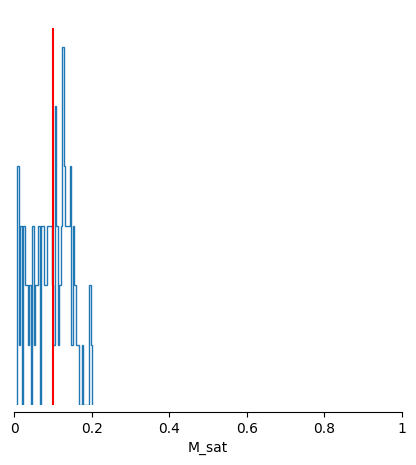

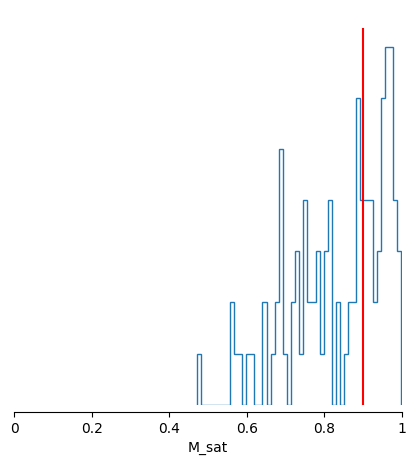

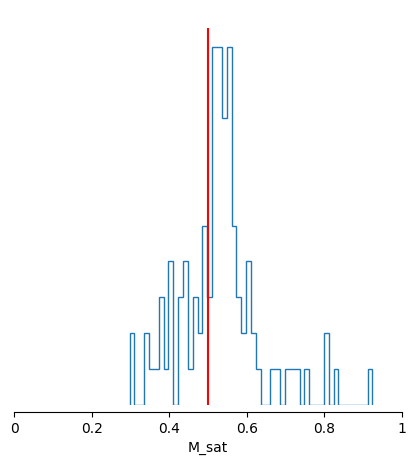

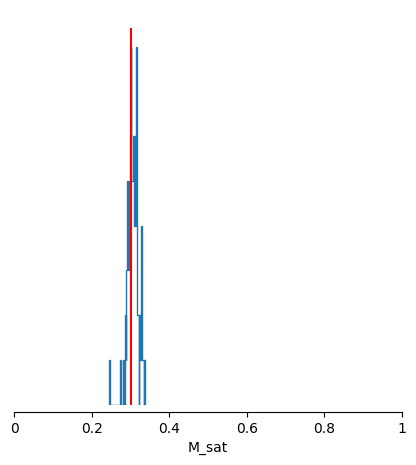

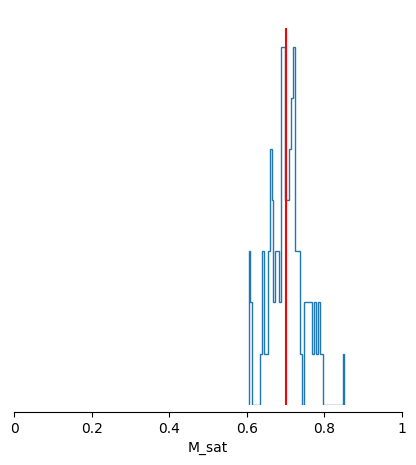

In [85]:
# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[0,1]], figsize=(5, 5), labels=["M_sat"], points=[0.1],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_2, limits=[[0,1]], figsize=(5, 5), labels=["M_sat"], points=[0.9],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_3, limits=[[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.5],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_4, limits=[[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.3],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_5, limits=[[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.7],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

with constant perturbation strength lines

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in true_divide


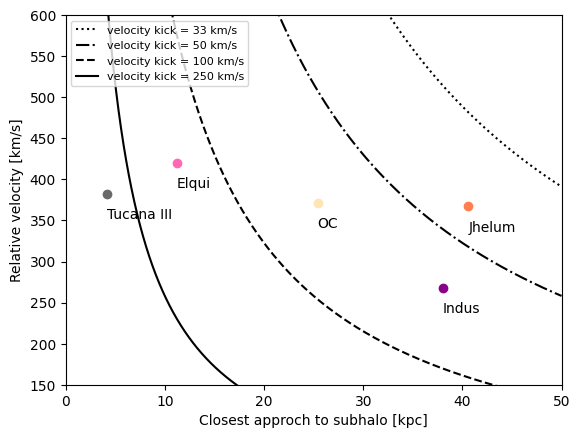

6.67e-11 2.985e+41 3.086e+20 33000.0


In [ ]:
G=6.67e-11
M= 15 # mass of subhalo in 1e10 Msun
#b= impact parameter in kpc
#w= relative velocity in km/s

#delta_v in km/s
delta_v1= 33
delta_v2= 50
delta_v3= 100
delta_v4= 250

# x axis: cloest approach to subhalo, i.e. impact parameter b
# y axis: relative velocity at cloest approach, w


b = np.arange(0.0, 50.0, 0.01)
w1 = G*(M*1.99e40)/(b*3.086e19)/(delta_v1*1e3)/1e3
plt.plot(b,w1, label=f'velocity kick = {delta_v1} km/s', linestyle='dotted', color='black')


w2 = G*(M*1.99e40)/(b*3.086e19)/(delta_v2*1e3)/1e3
_ = plt.plot(b,w2, label=f'velocity kick = {delta_v2} km/s', linestyle='-.', color='black')

w3 = G*(M*1.99e40)/(b*3.086e19)/(delta_v3*1e3)/1e3
_ = plt.plot(b,w3, label=f'velocity kick = {delta_v3} km/s', linestyle='--', color='black')

w4 = G*(M*1.99e40)/(b*3.086e19)/(delta_v4*1e3)/1e3
_ = plt.plot(b,w4, label=f'velocity kick = {delta_v4} km/s', color='black')

plt.legend(prop={'size':8})
plt.xlim(0, 50)
plt.ylim(150, 600)
plt.xlabel("Closest approch to subhalo [kpc]")
plt.ylabel("Relative velocity [km/s]")


# stream models as dots
x=[4.2, 11.2, 25.4, 40.6, 38]
y=[382, 420, 371, 367, 268]
streams=['Tucana III', 'Elqui', 'OC', 'Jhelum', 'Indus']
colors=['dimgray', 'hotpink','moccasin','coral','darkmagenta']
for i in range(5):
    plt.plot(x[i],y[i],'o', color=colors[i])
    plt.text(x[i],y[i]-30, streams[i])

plt.show()
print(G, (M*1.99e40), (10*3.086e19), (delta_v1*1e3))